In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Adjust the filename if you kept it as .csv.xls instead of renaming to .csv
df = pd.read_csv(r'D:\AI-Travel-Analyst\data\flight_pricing_dataset.csv')
# Show the first 5 rows
display(df.head())

# Show column names, non-null counts, and data types
df.info()

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,1.67,0,910.5,Economy,43,Monsoon,Saturday,Boeing 737,Mobile App,5,5181.56
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0h 45m,non-stop,150,Economy,45,Monsoon,Thursday,ATR 72,Website,3,2000
2,FL173851,Qatar Airways,Sydney,PNQ,2025-02-11,5:05 PM,7:53 AM,14.80,1 stop,10168.1,Economy,3,NaN,Tuesday,Boeing 777,Mobile App,3,174762.69
3,FL101953,AirAsia India,Bangalore Airport,BOM,2025-04-19,07:05,10:16 AM,3h 11m,1,868.3,Economy,33,Summer,Saturday,Airbus A320,Mobile App,1,2846.09
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,13.93,non-stop,10478.0,Economy,6,Monsoon,Sunday,Airbus A320,Website,2,145331.64


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   Flight_ID              100000 non-null  str  
 1   Airline                95120 non-null   str  
 2   Source                 95085 non-null   str  
 3   Destination            95119 non-null   str  
 4   Departure_Date         95073 non-null   str  
 5   Departure_Time         95132 non-null   str  
 6   Arrival_Time           95211 non-null   str  
 7   Duration               94958 non-null   str  
 8   Total_Stops            95095 non-null   str  
 9   Distance_km            95077 non-null   str  
 10  Travel_Class           95137 non-null   str  
 11  Days_Before_Departure  95216 non-null   str  
 12  Season                 95224 non-null   str  
 13  Weekday                95280 non-null   str  
 14  Aircraft_Type          95148 non-null   str  
 15  Booking_Channel        95038 

In [2]:
%pip install pandas numpy matplotlib seaborn


  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# 1. Drop rows with missing values
df = df.dropna().copy()

# 2. Convert number columns that were accidentally saved as text into real numbers
cols_to_numeric = ['Price', 'Distance_km', 'Passenger_Count', 'Days_Before_Departure']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Drop any rows where the number conversion failed
df = df.dropna().copy()

# Show the new row count and the fixed data types
print("Total rows after cleaning:", len(df))
print("\nData Types:")
print(df[cols_to_numeric].dtypes)

Total rows after cleaning: 38773

Data Types:
Price                    float64
Distance_km              float64
Passenger_Count          float64
Days_Before_Departure    float64
dtype: object


In [17]:
# 1. Clean Total_Stops column
def clean_stops(val):
    val = str(val).lower().strip()
    if 'non-stop' in val or '0' in val:
        return 0
    elif '1' in val:
        return 1
    elif '2' in val:
        return 2
    elif '3' in val:
        return 3
    else:
        return np.nan

df['Total_Stops'] = df['Total_Stops'].apply(clean_stops)

# 2. Clean Duration column to convert everything into hours
def clean_duration(val):
    val = str(val).strip().lower()
    if 'min' in val:
        minutes = float(val.replace('min', '').strip())
        return minutes / 60.0
    elif 'h' in val or 'm' in val:
        hours = 0
        minutes = 0
        parts = val.split()
        for p in parts:
            if 'h' in p:
                hours = float(p.replace('h', '').strip())
            elif 'm' in p:
                minutes = float(p.replace('m', '').strip())
        return hours + (minutes / 60.0)
    else:
        try:
            return float(val)
        except:
            return np.nan

df['Duration'] = df['Duration'].apply(clean_duration)

# 3. Drop any rows where these conversions failed
df = df.dropna().copy()

print("Rows left after cleaning stops and duration:", len(df))
display(df[['Total_Stops', 'Duration']].head())

Rows left after cleaning stops and duration: 38773


,Total_Stops,Duration
0,0,1.670000
1,0,0.750000
3,1,3.183333
4,0,13.930000
6,0,1.466667


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/visualizations/1_price_distribution.png'

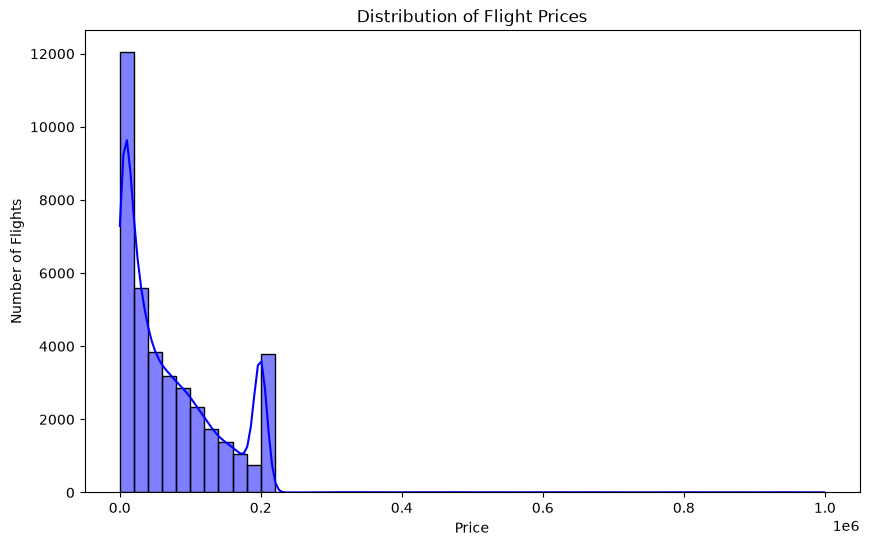

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Number of Flights')
plt.savefig('outputs/visualizations/1_price_distribution.png')
plt.show()


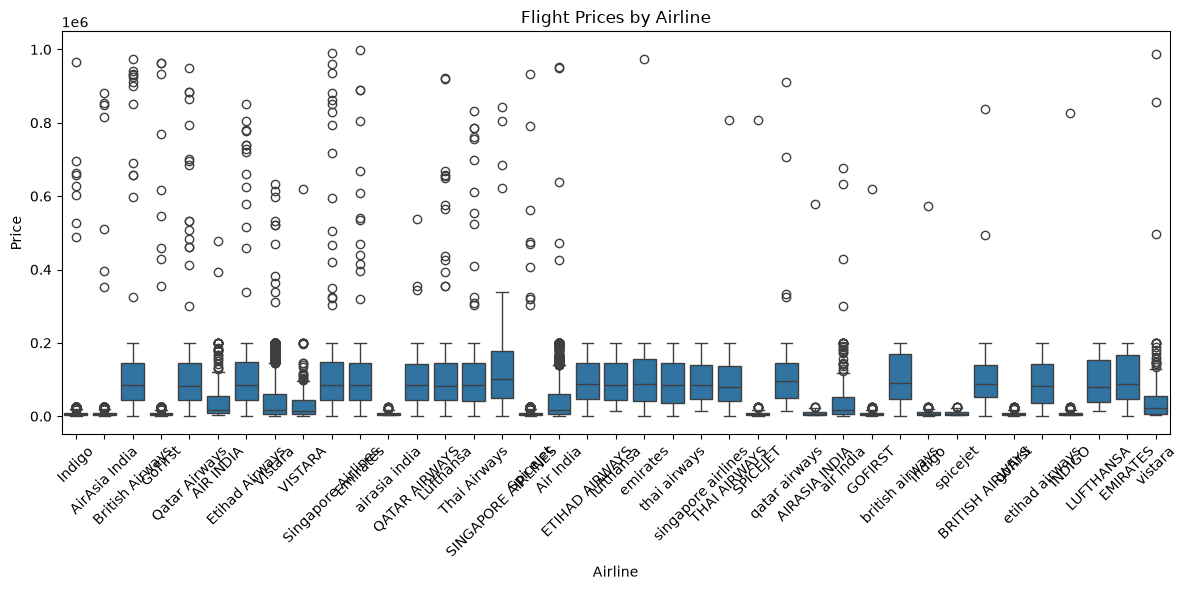

In [19]:
import os
# This fixes your folder error by creating the folder if it doesn't exist
os.makedirs('outputs/visualizations', exist_ok=True) 

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Airline', y='Price')
plt.title('Flight Prices by Airline')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/visualizations/2_airline_vs_price.png')
plt.show()

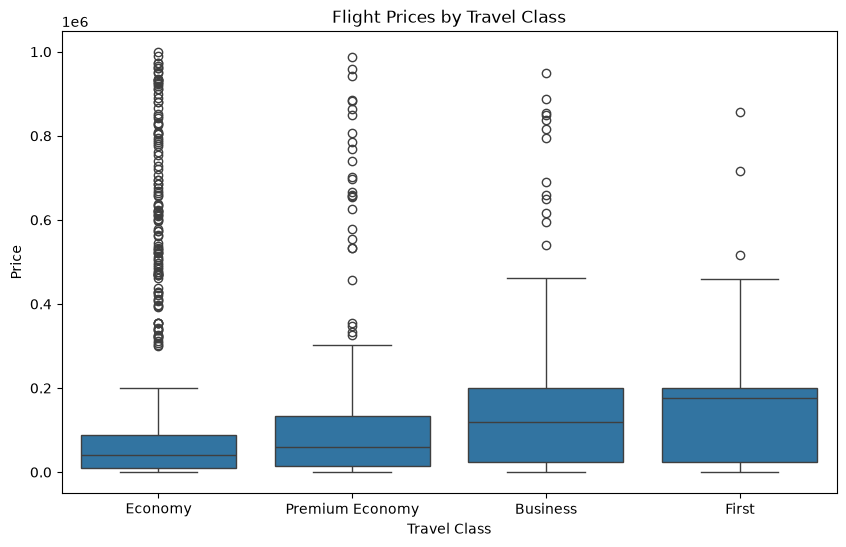

In [20]:
# First, fix the inconsistent capitalization in our text columns
df['Airline'] = df['Airline'].str.title().str.strip()
df['Travel_Class'] = df['Travel_Class'].str.title().str.strip()

# Now, create the 3rd visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Travel_Class', y='Price')
plt.title('Flight Prices by Travel Class')
plt.xlabel('Travel Class')
plt.ylabel('Price')
plt.savefig('outputs/visualizations/3_class_vs_price.png')
plt.show()

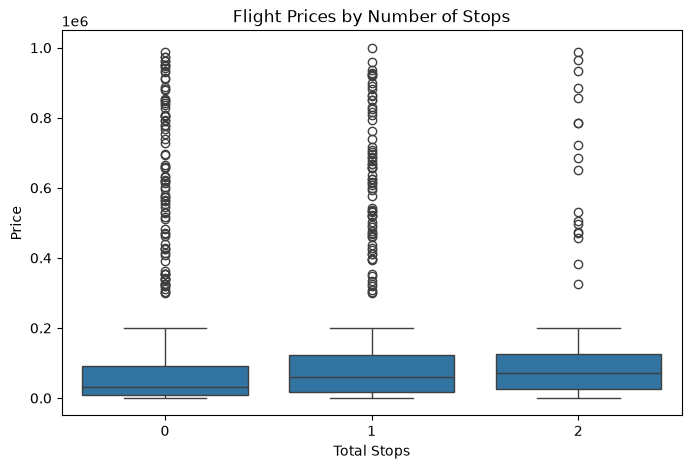

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Total_Stops', y='Price')
plt.title('Flight Prices by Number of Stops')
plt.xlabel('Total Stops')
plt.ylabel('Price')
plt.savefig('outputs/visualizations/4_stops_vs_price.png')
plt.show()

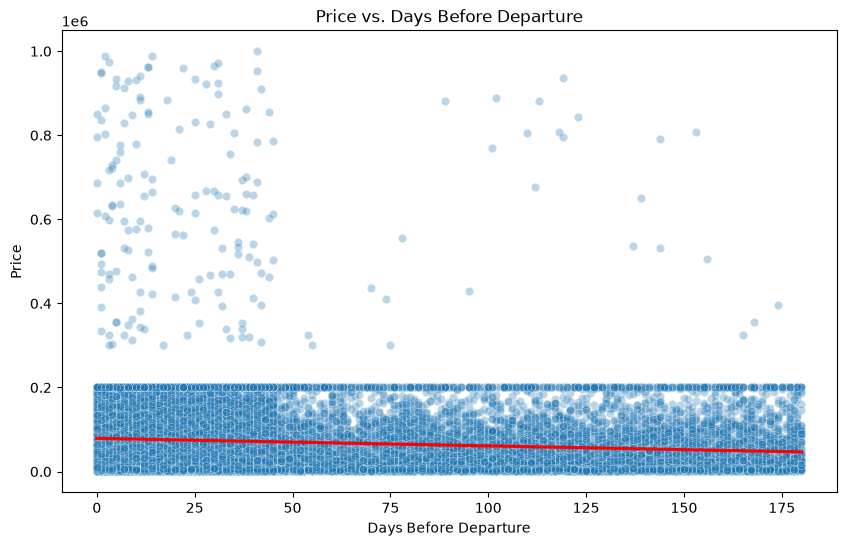

In [22]:
plt.figure(figsize=(10, 6))
# We will use a scatter plot, but with alpha (transparency) because there are many data points
sns.scatterplot(data=df, x='Days_Before_Departure', y='Price', alpha=0.3)
# Let's add a trendline to see the general direction
sns.regplot(data=df, x='Days_Before_Departure', y='Price', scatter=False, color='red')
plt.title('Price vs. Days Before Departure')
plt.xlabel('Days Before Departure')
plt.ylabel('Price')
plt.savefig('outputs/visualizations/5_days_vs_price.png')
plt.show()